<a href="https://colab.research.google.com/github/yohperez/vecdb/blob/main/Pildora_26_09_29_vector_db_con_visualizaciones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧭 Píldora: Arquitectura e Indexación de Bases de Datos Vectoriales
### De la fuerza bruta al `Disk-Native`: HNSW, IVF, PQ/OPQ y el triángulo de hierro

**Duración estimada:** 20 min de ejecución + lectura.
**Objetivo:** entender *por qué* la búsqueda vectorial a gran escala necesita ANN (Approximate Nearest Neighbor), y comparar con tus propias manos HNSW, IVF y IVF-PQ en recall, latencia y memoria.

**Índice**
1. El problema: `kNN` exacto colapsa a escala
2. HNSW — velocidad en memoria (grafos jerárquicos)
3. IVF — escalabilidad por clústeres (`nlist` / `nprobe`)
4. Product Quantization (PQ) — comprimiendo la memoria
5. El triángulo de hierro: Recall vs Latencia vs Memoria
6. Filtrado de metadatos: pre-filtrado vs post-filtrado vs single-stage
7. Cierre + reto final

> Al terminar, pasa al quiz interactivo para consolidar los conceptos.


Este Colab es una excelente introducción práctica a las complejidades y soluciones en la búsqueda de vectores a gran escala, mostrando cómo optimizar el balance entre `recall` (precisión de la búsqueda), `latencia` (velocidad de respuesta) y `memoria` (consumo de RAM).

Aquí tienes un resumen de los puntos clave que aborda:

1.  **El problema del kNN exacto a escala**: La búsqueda exacta de los 'k' vecinos más cercanos (`kNN`) es 100% precisa pero computacionalmente costosa (`O(N × D)`). Esto significa que su latencia crece linealmente con el número de vectores (`N`) y la dimensionalidad (`D`), haciéndola inviable para datasets grandes (más de ~100K vectores).

2.  **HNSW (Hierarchical Navigable Small World)**: Se presenta como una solución ANN (Approximate Nearest Neighbor) de bajo consumo de latencia y alto recall. HNSW construye un grafo multi-capa donde la búsqueda empieza en capas de baja densidad (saltos largos) y desciende a capas de alta densidad (refinamiento local), optimizando la ruta. Aunque es muy rápido y preciso, su principal desventaja es el alto consumo de RAM debido a la necesidad de almacenar el grafo.

3.  **IVF (Inverted File Index)**: Esta técnica aborda la escalabilidad dividiendo el espacio vectorial en `nlist` clústeres. Durante la búsqueda, solo se exploran `nprobe` clústeres más cercanos a la consulta, reduciendo significativamente el número de vectores a escanear. Esto mejora la latencia y la eficiencia, pero tiene un 'trade-off' de recall si `nprobe` es demasiado bajo y la consulta 'pierde' vecinos importantes en clústeres no explorados.

4.  **PQ (Product Quantization)**: Es una técnica de compresión que divide los vectores en sub-vectores y los codifica contra 'codebooks', transformando `float32` a `int8`. Esto permite una compresión de hasta 32x, haciendo posible almacenar miles de millones de vectores en RAM, especialmente cuando se combina con IVF (`IVF-PQ`). Es una solución estándar en producción para grandes volúmenes de datos, ya que ofrece un equilibrio óptimo entre velocidad de escaneo y bajo consumo de memoria, aunque con una ligera pérdida de recall.

5.  **El Triángulo de Hierro (Recall vs Latencia vs Memoria)**: El notebook ilustra vívidamente que no hay un índice "talla única". Optimizar un aspecto (ej. latencia) casi siempre implica sacrificar otro (ej. recall o memoria). La elección del índice debe basarse en los requisitos específicos de tu aplicación, como la cantidad de datos, las expectativas de rendimiento y los recursos disponibles.

En resumen, este Colab te permite ver y experimentar cómo diferentes algoritmos de indexación de bases de datos vectoriales (`Flat`, `HNSW`, `IVF`, `IVF-PQ`) abordan el desafío de la búsqueda de vecinos más cercanos a escala, destacando los compromisos inherentes entre recall, latencia y uso de memoria. También se toca el importante tema del **filtrado de metadatos** y el "dilema arquitectónico" que presenta.

¡Espero que esta "Píldora" te sea muy útil para entender y aplicar estos conceptos!

## 0. Setup
Instalamos `faiss-cpu` (la librería de referencia para HNSW/IVF/PQ) y utilidades básicas.

In [ ]:
!pip install -q faiss-cpu numpy matplotlib

import time
import numpy as np
import faiss
import matplotlib.pyplot as plt

np.random.seed(42)
print("faiss version:", faiss.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 75.4 MB/s eta 0:00:00
faiss version: 1.15.1


## 1. El problema: la fuerza bruta colapsa a escala

Búsqueda exacta (`kNN`, índice `Flat`) tiene complejidad **O(N × D)** por consulta: recorre *todos* los vectores.
Precisión 100%, pero la latencia crece linealmente con `N`. Práctico solo por debajo de ~100K vectores.

Generamos un dataset sintético de embeddings (simulando salidas de un modelo tipo `text-embedding-*`) y medimos el costo de la búsqueda exacta.

In [ ]:
N = 200_000      # nº de vectores en la base
D = 128          # dimensionalidad (embeddings reales suelen ser 384-1536)
N_QUERIES = 200

xb = np.random.random((N, D)).astype('float32')   # "base de datos"
xq = np.random.random((N_QUERIES, D)).astype('float32')  # consultas
k = 10  # top-k vecinos

index_flat = faiss.IndexFlatL2(D)
index_flat.add(xb)

t0 = time.time()
D_flat, I_flat = index_flat.search(xq, k)
t_flat = time.time() - t0

print(f"Índice Flat (kNN exacto): {N:,} vectores, D={D}")
print(f"Latencia total: {t_flat*1000:.1f} ms  |  por consulta: {t_flat/N_QUERIES*1000:.3f} ms")
print("Recall = 100% (es la verdad fundamental: la usamos como referencia para medir a los demás)")


Índice Flat (kNN exacto): 200,000 vectores, D=128
Latencia total: 2532.2 ms  |  por consulta: 12.661 ms
Recall = 100% (es la verdad fundamental: la usamos como referencia para medir a los demás)


In [8]:
import ipywidgets as widgets
from IPython.display import display, HTML

def run_flat_index_experiment(num_vectors, dimensions, top_k):
    N_QUERIES = 200 # Keeping N_QUERIES constant as in the original example

    # Generate synthetic data
    xb_interactive = np.random.random((num_vectors, dimensions)).astype('float32')
    xq_interactive = np.random.random((N_QUERIES, dimensions)).astype('float32')

    # Create and train the Flat index
    index_flat_interactive = faiss.IndexFlatL2(dimensions)
    index_flat_interactive.add(xb_interactive)

    # Perform the search and measure latency
    t0 = time.time()
    D_flat_interactive, I_flat_interactive = index_flat_interactive.search(xq_interactive, top_k)
    t_flat_interactive = time.time() - t0

    # Display results
    display(HTML(f"<b>Resultados para Flat Index:</b><br/>"
                 f"N (Vectores): {num_vectors:,}<br/>"
                 f"D (Dimensionalidad): {dimensions}<br/>"
                 f"k (Top-k vecinos): {top_k}<br/>"
                 f"Latencia total: {t_flat_interactive*1000:.1f} ms<br/>"
                 f"Latencia por consulta: {t_flat_interactive/N_QUERIES*1000:.3f} ms<br/>"
                 f"Recall = 100% (es la verdad fundamental)"))

# Create interactive widgets
num_vectors_slider = widgets.IntSlider(
    value=N, # Default to the value from the previous cell
    min=10_000,
    max=500_000,
    step=10_000,
    description='N (Vectores):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

dimensions_slider = widgets.IntSlider(
    value=D, # Default to the value from the previous cell
    min=32,
    max=512,
    step=32,
    description='D (Dimensionalidad):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

top_k_slider = widgets.IntSlider(
    value=k, # Default to the value from the previous cell
    min=1,
    max=50,
    step=1,
    description='k (Top-k):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# Link widgets to the function
interactive_plot = widgets.interactive(run_flat_index_experiment,
                                       num_vectors=num_vectors_slider,
                                       dimensions=dimensions_slider,
                                       top_k=top_k_slider)

display(interactive_plot)

interactive(children=(IntSlider(value=200000, continuous_update=False, description='N (Vectores):', max=500000…

## 2. HNSW — grafos de navegación jerárquica

HNSW construye capas de grafos: la consulta entra por la capa superior dispersa (saltos largos / "autopistas")
y desciende iterativamente refinando la precisión hasta la capa inferior densa ("calles locales").

**Métricas de diseño:** latencia ultra-baja (<20ms), recall altísimo (95-99%).
**Cuello de botella:** consumo de RAM masivo (`4×D×N + M×N×8` bytes aprox., por vectores + aristas del grafo).

Parámetros clave:
- `M`: nº de conexiones por nodo (más M = más recall, más memoria)
- `efConstruction`: calidad de construcción del grafo
- `efSearch`: calidad de la búsqueda (trade-off recall/latencia en tiempo de consulta)

In [ ]:
def recall_at_k(I_approx, I_truth, k):
    hits = 0
    for approx, truth in zip(I_approx, I_truth):
        hits += len(set(approx[:k]) & set(truth[:k]))
    return hits / (len(I_approx) * k)

M = 32
index_hnsw = faiss.IndexHNSWFlat(D, M)
index_hnsw.hnsw.efConstruction = 64
index_hnsw.add(xb)

results = []
for ef_search in [16, 32, 64, 128]:
    index_hnsw.hnsw.efSearch = ef_search
    t0 = time.time()
    D_h, I_h = index_hnsw.search(xq, k)
    t_h = time.time() - t0
    rec = recall_at_k(I_h, I_flat, k)
    lat_ms = t_h / N_QUERIES * 1000
    results.append(("HNSW", ef_search, rec, lat_ms))
    print(f"efSearch={ef_search:4d}  recall={rec:.3f}  latencia/query={lat_ms:.3f} ms")

print("\n→ Observa cómo subir efSearch acerca el recall a 1.0 a costa de latencia: el trade-off en vivo.")


In [9]:
import ipywidgets as widgets
from IPython.display import display, HTML

def run_hnsw_experiment_interactive(M_hnsw, ef_construction_hnsw, ef_search_hnsw):
    # Recreate index for new M and efConstruction
    # Note: Adding to the index is an expensive operation.
    # For a real-time interactive experience with many updates, consider optimizing
    # or pre-building multiple indices, or accepting a slight delay for re-indexing.
    index_hnsw_interactive = faiss.IndexHNSWFlat(D, M_hnsw)
    index_hnsw_interactive.hnsw.efConstruction = ef_construction_hnsw
    index_hnsw_interactive.add(xb) # xb, D are from the global scope

    # Perform search with the new efSearch parameter
    index_hnsw_interactive.hnsw.efSearch = ef_search_hnsw
    t0 = time.time()
    D_h_interactive, I_h_interactive = index_hnsw_interactive.search(xq, k) # xq, k are from global scope
    t_h_interactive = time.time() - t0

    rec = recall_at_k(I_h_interactive, I_flat, k) # recall_at_k and I_flat are from global scope
    lat_ms = t_h_interactive / N_QUERIES * 1000 # N_QUERIES is from global scope

    display(HTML(f"<b>Resultados Interactivos para HNSW:</b><br/>"
                 f"M (conexiones por nodo): {M_hnsw}<br/>"
                 f"efConstruction: {ef_construction_hnsw}<br/>"
                 f"efSearch: {ef_search_hnsw}<br/>"
                 f"Recall@{k}: {rec:.3f}<br/>"
                 f"Latencia por consulta: {lat_ms:.3f} ms"))

# Create interactive widgets
M_hnsw_slider = widgets.IntSlider(
    value=M, # Default to the value from the previous cell
    min=8,
    max=64,
    step=8,
    description='M (HNSW):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

ef_construction_slider = widgets.IntSlider(
    value=64, # Default value used in the previous example
    min=16,
    max=128,
    step=16,
    description='efConstruction:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

ef_search_slider = widgets.IntSlider(
    value=64, # Default value around the middle of typical range
    min=16,
    max=256,
    step=16,
    description='efSearch:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# Link widgets to the function
interactive_hnsw = widgets.interactive(run_hnsw_experiment_interactive,
                                       M_hnsw=M_hnsw_slider,
                                       ef_construction_hnsw=ef_construction_slider,
                                       ef_search_hnsw=ef_search_slider)

display(interactive_hnsw)


interactive(children=(IntSlider(value=32, continuous_update=False, description='M (HNSW):', max=64, min=8, ste…

## 3. IVF — Inverted File Index: escalar dividiendo el espacio

IVF particiona el espacio vectorial en `nlist` clústeres (celdas de Voronoi). En consulta, solo se exploran
`nprobe` clústeres vecinos al centroide más cercano — en vez de escanear todo el dataset.

- `nlist` alto → particiones más finas, pero cada una necesita más `nprobe` para no perder vecinos en los bordes.
- `nprobe` bajo → muy rápido pero puede sufrir el "problema de los bordes" (vectores similares separados por la línea del clúster) y perder recall.

In [ ]:
nlist = 100
quantizer = faiss.IndexFlatL2(D)
index_ivf = faiss.IndexIVFFlat(quantizer, D, nlist)
index_ivf.train(xb)
index_ivf.add(xb)

print(f"IVF con nlist={nlist}\n")
for nprobe in [1, 5, 10, 20, 50]:
    index_ivf.nprobe = nprobe
    t0 = time.time()
    D_i, I_i = index_ivf.search(xq, k)
    t_i = time.time() - t0
    rec = recall_at_k(I_i, I_flat, k)
    lat_ms = t_i / N_QUERIES * 1000
    results.append(("IVF", nprobe, rec, lat_ms))
    print(f"nprobe={nprobe:3d}  recall={rec:.3f}  latencia/query={lat_ms:.3f} ms")

print("\n→ Con nprobe=nlist estarías escaneando todo: mismo recall que Flat, pero perdiste la ventaja de velocidad.")


In [10]:
import ipywidgets as widgets
from IPython.display import display, HTML

def run_ivf_experiment_interactive(nlist_ivf, nprobe_ivf):
    # Recreate and retrain index for new nlist
    # Note: Training IVF is a clustering step and can be time-consuming for large N.
    # For a truly real-time interactive experience with many updates, consider optimizing
    # or pre-building multiple indices, or accepting a slight delay for re-indexing.
    quantizer_interactive = faiss.IndexFlatL2(D)
    index_ivf_interactive = faiss.IndexIVFFlat(quantizer_interactive, D, nlist_ivf)
    index_ivf_interactive.train(xb) # xb, D are from global scope
    index_ivf_interactive.add(xb)

    # Perform search with new nprobe
    index_ivf_interactive.nprobe = nprobe_ivf
    t0 = time.time()
    D_i_interactive, I_i_interactive = index_ivf_interactive.search(xq, k) # xq, k are from global scope
    t_i_interactive = time.time() - t0

    rec = recall_at_k(I_i_interactive, I_flat, k) # recall_at_k and I_flat are from global scope
    lat_ms = t_i_interactive / N_QUERIES * 1000 # N_QUERIES is from global scope

    display(HTML(f"<b>Resultados Interactivos para IVF:</b><br/>"
                 f"nlist (clústeres): {nlist_ivf}<br/>"
                 f"nprobe (clústeres a buscar): {nprobe_ivf}<br/>"
                 f"Recall@{k}: {rec:.3f}<br/>"
                 f"Latencia por consulta: {lat_ms:.3f} ms"))

# Create interactive widgets
nlist_slider = widgets.IntSlider(
    value=nlist, # Default to the value from the previous cell
    min=10,
    max=500,
    step=10,
    description='nlist:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

nprobe_slider = widgets.IntSlider(
    value=10, # Default to a common starting value
    min=1,
    max=50,
    step=1,
    description='nprobe:',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)

# Link widgets to the function
interactive_ivf = widgets.interactive(run_ivf_experiment_interactive,
                                      nlist_ivf=nlist_slider,
                                      nprobe_ivf=nprobe_slider)

display(interactive_ivf)

interactive(children=(IntSlider(value=100, continuous_update=False, description='nlist:', max=500, min=10, ste…

## 4. Product Quantization (PQ) — rompiendo la barrera de RAM

PQ divide cada vector en sub-vectores y los codifica contra un *codebook* (diccionario K-Means), comprimiendo
`float32` → `int8`. Logra compresiones de hasta 32x, permitiendo alojar miles de millones de vectores en RAM
mediante *Asymmetric Distance Computation* (ADC), a cambio de una leve pérdida de recall.

`IVF + PQ` es el caballo de batalla estándar en producción para cargas de 100M–1B de vectores: equilibrio
óptimo entre velocidad de escaneo y bajo consumo de memoria.

In [ ]:
m_subquantizers = 16   # D debe ser divisible por m
bits = 8

index_ivfpq = faiss.IndexIVFPQ(quantizer, D, nlist, m_subquantizers, bits)
index_ivfpq.train(xb)
index_ivfpq.add(xb)
index_ivfpq.nprobe = 10

t0 = time.time()
D_pq, I_pq = index_ivfpq.search(xq, k)
t_pq = time.time() - t0
rec_pq = recall_at_k(I_pq, I_flat, k)

# Footprint de memoria aproximado
mem_flat_mb = xb.nbytes / (1024**2)
mem_pq_mb = (N * m_subquantizers * bits / 8) / (1024**2)  # códigos comprimidos

print(f"IVF-PQ (m={m_subquantizers}, nprobe=10)")
print(f"recall={rec_pq:.3f}  latencia/query={(t_pq/N_QUERIES)*1000:.3f} ms")
print(f"\nMemoria vectores crudos (float32): {mem_flat_mb:.1f} MB")
print(f"Memoria códigos IVF-PQ (int8):      {mem_pq_mb:.1f} MB")
print(f"Factor de compresión:               {mem_flat_mb/mem_pq_mb:.1f}x")
results.append(("IVF-PQ", "nprobe=10", rec_pq, (t_pq/N_QUERIES)*1000))


## 5. El triángulo de hierro: Recall vs Latencia vs Memoria

No existe el índice perfecto: optimizar un vértice siempre implica sacrificar los otros dos.
Visualicemos todos los experimentos anteriores en un único gráfico latencia-vs-recall.

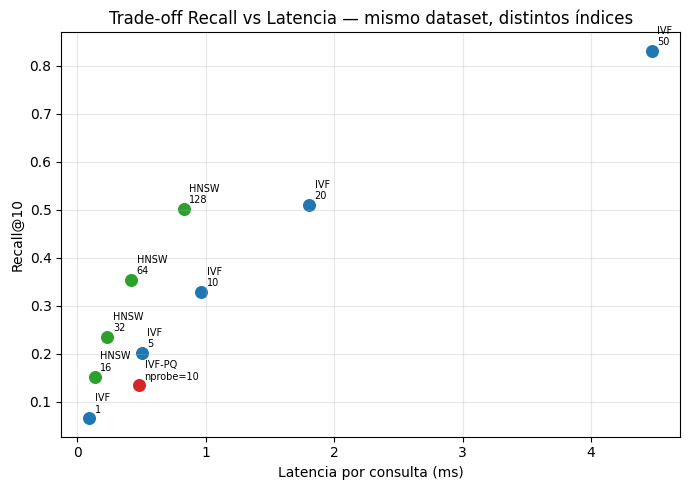

HNSW → esquina superior-izquierda (rápido y preciso, pero caro en RAM).
IVF-PQ → memoria mínima, buen equilibrio; ideal para 100M-1B de vectores.


In [12]:
fig, ax = plt.subplots(figsize=(7,5))
colors = {"HNSW": "tab:green", "IVF": "tab:blue", "IVF-PQ": "tab:red"}
for algo, param, rec, lat in results:
    ax.scatter(lat, rec, color=colors[algo], s=70)
    ax.annotate(f"{algo}\n{param}", (lat, rec), fontsize=7, xytext=(4,4), textcoords='offset points')

ax.set_xlabel("Latencia por consulta (ms)")
ax.set_ylabel("Recall@%d" % k)
ax.set_title("Trade-off Recall vs Latencia — mismo dataset, distintos índices")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("HNSW → esquina superior-izquierda (rápido y preciso, pero caro en RAM).")
print("IVF-PQ → memoria mínima, buen equilibrio; ideal para 100M-1B de vectores.")


## 6. Filtrado de metadatos: el dilema arquitectónico

Cuando además del vector filtras por metadatos (`tenant_id`, `fecha`, `categoría`...), hay tres vías:

| Vía | Descripción | Riesgo |
|---|---|---|
| **Pre-filtrado** | Filtra antes de buscar en el índice | Preciso, pero destruye la topología del grafo ANN (grafos huérfanos) |
| **Post-filtrado** | Busca primero, filtra después | Rapidísimo, pero puede devolver **0 resultados** si el filtro es estricto |
| **Single-stage (in-search)** | Evalúa el filtro (bitset) *mientras* recorre el grafo | Estándar de oro moderno: mantiene topología y recall |

Simulemos el problema del post-filtrado ingenuo:

In [11]:
# Simulamos metadatos: solo el 2% de los vectores cumple un filtro estricto
mask = np.random.random(N) < 0.02
print(f"Vectores que cumplen el filtro: {mask.sum()} de {N} ({mask.mean()*100:.1f}%)")

# Post-filtrado ingenuo: buscamos top-k=10 SIN filtrar, y filtramos después
D_naive, I_naive = index_hnsw.search(xq[:1], 10)
sobrevivientes = mask[I_naive[0]]
print(f"\nPost-filtrado: de los 10 vecinos más cercanos devueltos, "
      f"solo {sobrevivientes.sum()} cumplen el filtro.")
print("→ Si el filtro fuese aún más estricto, esto puede devolver una lista vacía: el problema real del post-filtrado.")
print("→ La solución en producción (single-stage) integra el bitset del filtro dentro del propio recorrido del grafo.")


Vectores que cumplen el filtro: 3987 de 200000 (2.0%)

Post-filtrado: de los 10 vecinos más cercanos devueltos, solo 0 cumplen el filtro.
→ Si el filtro fuese aún más estricto, esto puede devolver una lista vacía: el problema real del post-filtrado.
→ La solución en producción (single-stage) integra el bitset del filtro dentro del propio recorrido del grafo.


## 7. Cierre y reto final

**Lo que ya sabes hacer:**
- Explicar por qué `kNN` exacto no escala (`O(N×D)`)
- Construir y tunear HNSW (`efSearch`) e IVF (`nprobe`)
- Medir el trade-off recall/latencia/memoria de forma empírica
- Reconocer el problema del post-filtrado ingenuo

### 🎯 Reto (opcional, 10 min)
1. Sube `D` a 512 y repite el experimento de HNSW vs IVF-PQ. ¿Cómo cambia la memoria de HNSW?
2. Combina `IVF-PQ` con `nprobe` variable y traza tu propia curva recall-latencia.
3. Consulta la tabla de framework de decisión: para tu caso de uso (¿RAG? ¿recomendador? ¿búsqueda offline masiva?), ¿qué índice elegirías y por qué?

➡️ Cuando termines, haz el **quiz interactivo** para consolidar los conceptos de la píldora.

In [13]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt

# The global variables N, D, xb, xq, k, I_flat, N_QUERIES, results are assumed to be available

def run_ivfpq_curve_interactive(nlist_ivfpq, m_subquantizers_ivfpq, bits_ivfpq, nprobe_start, nprobe_end, nprobe_step):
    current_ivfpq_curve_data = []

    # Check if D is divisible by m_subquantizers_ivfpq, if not, adjust m or skip
    if D % m_subquantizers_ivfpq != 0:
        display(HTML(f"<p style='color:red;'>Error: La dimensionalidad (D={D}) debe ser divisible por m_subquantizers (actual={m_subquantizers_ivfpq}). Por favor, ajusta 'm'.</p>"))
        return

    # Create and train the IVF-PQ index
    quantizer_interactive = faiss.IndexFlatL2(D)
    index_ivfpq_interactive = faiss.IndexIVFPQ(quantizer_interactive, D, nlist_ivfpq, m_subquantizers_ivfpq, bits_ivfpq)
    index_ivfpq_interactive.train(xb)
    index_ivfpq_interactive.add(xb)

    # Generate curve for varying nprobe
    # Ensure nprobe values are within valid range [1, nlist_ivfpq]
    effective_nprobe_end = min(nprobe_end, nlist_ivfpq)
    nprobe_values = range(nprobe_start, effective_nprobe_end + 1, nprobe_step)

    if not nprobe_values:
        if nprobe_start <= nlist_ivfpq:
            nprobe_values = [nprobe_start]
        else:
            display(HTML(f"<p style='color:red;'>Error: Rango de nprobe inválido. nprobe_start ({nprobe_start}) es mayor que nlist ({nlist_ivfpq}).</p>"))
            return

    for nprobe_val in nprobe_values:
        index_ivfpq_interactive.nprobe = nprobe_val
        t0 = time.time()
        _, I_pq_interactive = index_ivfpq_interactive.search(xq, k)
        t_pq_interactive = time.time() - t0

        rec = recall_at_k(I_pq_interactive, I_flat, k)
        lat_ms = t_pq_interactive / N_QUERIES * 1000
        current_ivfpq_curve_data.append((nprobe_val, rec, lat_ms))

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {"HNSW": "tab:green", "IVF": "tab:blue", "IVF-PQ": "tab:red"}

    # Plot existing results for context
    for algo, param, rec, lat in results:
        ax.scatter(lat, rec, color=colors[algo] if algo in colors else 'gray', s=70, alpha=0.6)
        ax.annotate(f"{algo}\n{param}", (lat, rec), fontsize=7, xytext=(4,4), textcoords='offset points')

    # Plot dynamically generated IVF-PQ curve
    if current_ivfpq_curve_data:
        ivfpq_lats = [item[2] for item in current_ivfpq_curve_data]
        ivfpq_recs = [item[1] for item in current_ivfpq_curve_data]
        nprobe_labels = [item[0] for item in current_ivfpq_curve_data]

        ax.plot(ivfpq_lats, ivfpq_recs, color=colors["IVF-PQ"], linestyle='--', marker='o', label='IVF-PQ (Curva dinámica)')
        for i, txt in enumerate(nprobe_labels):
            ax.annotate(f"nprobe={txt}", (ivfpq_lats[i], ivfpq_recs[i]), fontsize=7, xytext=(4,4), textcoords='offset points')

    ax.set_xlabel("Latencia por consulta (ms)")
    ax.set_ylabel(f"Recall@{k}")
    ax.set_title("Trade-off Recall vs Latencia para IVF-PQ (Curva de nprobe)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close(fig) # Close the figure to free up memory

# Define sliders for IVF-PQ parameters
nlist_ivfpq_slider = widgets.IntSlider(
    value=nlist, # Default from previous cell
    min=10, max=500, step=10,
    description='nlist (IVF-PQ):',
    continuous_update=False, readout=True, readout_format='d'
)

m_subquantizers_slider = widgets.IntSlider(
    value=m_subquantizers, # Default from previous cell
    min=4, max=min(D, 64), step=4, # D must be divisible by m, max 64 for reasonable computation
    description='m (Sub-cuant.):',
    continuous_update=False, readout=True, readout_format='d'
)

bits_ivfpq_slider = widgets.IntSlider(
    value=bits, # Default from previous cell
    min=4, max=8, step=1,
    description='bits por código:',
    continuous_update=False, readout=True, readout_format='d'
)

# Sliders for nprobe range (for generating the curve)
nprobe_start_slider = widgets.IntSlider(
    value=1,
    min=1, max=nlist, step=1,
    description='nprobe (inicio):',
    continuous_update=False, readout=True, readout_format='d'
)

nprobe_end_slider = widgets.IntSlider(
    value=min(20, nlist), # Default end, reasonable cap
    min=1, max=nlist, step=1, # nprobe cannot exceed nlist
    description='nprobe (fin):',
    continuous_update=False, readout=True, readout_format='d'
)

nprobe_step_slider = widgets.IntSlider(
    value=5,
    min=1, max=min(10, nlist),
    description='nprobe (paso):',
    continuous_update=False, readout=True, readout_format='d'
)

# Link widgets to the function
interactive_ivfpq_curve = widgets.interactive(
    run_ivfpq_curve_interactive,
    nlist_ivfpq=nlist_ivfpq_slider,
    m_subquantizers_ivfpq=m_subquantizers_slider,
    bits_ivfpq=bits_ivfpq_slider,
    nprobe_start=nprobe_start_slider,
    nprobe_end=nprobe_end_slider,
    nprobe_step=nprobe_step_slider
)

display(interactive_ivfpq_curve)

interactive(children=(IntSlider(value=100, continuous_update=False, description='nlist (IVF-PQ):', max=500, mi…